# Витрина данных в Яндекс Такси.

## Описание проекта

Цель: Построение витрины данных, которая будет агрегировать информацию о поездках по каждому способу оплаты. 

Задача: Написать PySpark-скрипт, который рассчитает ключевые показатели: количество поездок, среднюю стоимость поездки, средние чаевые и суммарную выручку по каждому типу оплаты.
Чтобы процесс был полностью автоматическим и не зависел от ручных запусков, необходимо создать DAG в Airflow. Этот DAG должен ежедневно:

* проверять наличие новых файлов с данными;

* запускать Spark-задачу;

* формировать обновлённую итоговую таблицу.

Эта таблица станет основой для финансовых отчётов и аналитических дашбордов.

## Описание данных

Таблица `taxi_data` содержит данные об активности пользователей и состоит из следующих полей:

* `taxi_id` — идентификатор водителя;

* `trip_start_timestamp` — время начала поездки;

* `trip_end_timestamp` — время окончания поездки;

* `trip_seconds` — длительность поездки в секундах;

* `trip_miles` — дистанция поездки;

* `fare` — стоимость поездки;

* `tips` — размер чаевых;

* `trip_total` — общая стоимость поездки: стоимость поездки + чаевые + комиссия;

* `payment_type` — способ оплаты.

## Что нужно сделать

1. Сначала необходимо написать Spark-скрипт, который будет обрабатывать данные о поездках и агрегировать показатели по способам оплаты `payment_type`. Понадобится рассчитать несколько показателей:

* количество поездок, которое показывает общий спрос и загрузку сервиса;
* среднюю стоимость `fare`, которое отражает уровень среднего чека поездки;
* средние чаевые `tips` — индикатор удовлетворённости клиентов и мотивации водителей;
* суммарную выручку `trip_total` — ключевой показатель дохода компании.

Все результаты должны собираться в одну итоговую таблицу `taxi_payment_summary`. После этого таблицу нужно записать в ClickHouse с помощью JDBC-драйвера.

2. Далее понадобится настроить DAG в Airflow. DAG должен запускаться ежедневно. Перед запуском он проверяет наличие файла с данными за нужную дату в S3-хранилище и только после появления файла запускает Spark-задачу.


## Шаг 1. Настройка Spark-агрегации

Данные хранятся в формате Parquet, поэтому для чтения используйте метод `spark.read.parquet()`. 

Данные необходимо сгруппировать по полю `payment_type` и рассчитать четыре показателя:

* количество поездок — `count(*)`;
* среднюю стоимость — `avg(...)`;
* средние чаевые — `avg(...)`;
* суммарную выручку — `sum(...)`.

Так получится витрина для анализа информации по каждому способу оплаты. 
После этого необходимо настроить запись полученной таблицы в ClickHouse.

In [ ]:
#filename=my_spark_job.py

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Создаём Spark-сессию и при необходимости добавляем конфигурации
spark = SparkSession.builder.appName("myAggregateTest").config("fs.s3a.endpoint", "storage.yandexcloud.net").getOrCreate()

# Указываем порт и параметры кластера ClickHouse
jdbcPort = 8443
jdbcHostname = "rc1a-3jouval14nne7aun.mdb.yandexcloud.net"
username = "da_20251229_b1f7537fe5"
jdbcDatabase = "playground_" + username
jdbcUrl = f"jdbc:clickhouse://{jdbcHostname}:{jdbcPort}/{jdbcDatabase}?ssl=true"
password = "b7f7a44ed853403f8f04e40bee49d45b"

# Считываем исходные данные
df = spark.read.parquet(f"s3a://da-plus-dags/project_04/taxi_data.parquet")

# Агрегируем данные по типам оплаты
taxi_payment_summary = df.groupBy("payment_type").agg(
    F.count("*").alias("trip_count"),
    F.avg("fare").alias("avg_fares"), 
    F.avg("tips").alias("avg_tips"), 
    F.sum("trip_total").alias("trip_total")
)

taxi_payment_summary.write.format("jdbc") \
    .option("url", jdbcUrl) \
    .option("user", username) \
    .option("password", password) \
    .option("dbtable", "taxi_data_aggregate") \
    .mode('append') \
    .save()

## Шаг 2. Настройка DAG

В DAG будет использован `S3KeySensor`, чтобы дождаться появления файла в S3. 
После этого будет запущен `DataprocCreatePysparkJobOperator`, передав путь к вашему скрипту. 
Дополнительный класс-оператор создавать не требуется.

In [ ]:
from datetime import datetime
from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

DAG_ID = "taxi_data_analysis"

with DAG(
    DAG_ID,
    schedule='@daily',
    start_date=datetime(2025,1,1),
    tags=['project_taxi'],
    catchup=False
) as dag:
    # 1) Ждём появления входного файла в S3
    wait_for_input = S3KeySensor(
        task_id='data_s3_sensor',
        poke_interval=300,
        timeout=3600,
        bucket_name="da-plus-dags",
        bucket_key="project_04/taxi_data.parquet",
        mode='poke',
        aws_conn_id='s3',
        wildcard_match=False
    )

    user = 'da_20251229_b1f7537fe5'

    # 2) Запускаем PySpark-задание на кластере Dataproc (оператор Яндекс Облака)
    run_pyspark = DataprocCreatePysparkJobOperator(
        name='create_aggregate_and_load_to_ch',
        task_id='run_pyspark',
        cluster_id='c9q4134h5vi546h1e148',
        main_python_file_uri=f"s3a://da-plus-dags/{user}/jobs/my_spark_job.py"
)
    # 3)  Зависимости 
wait_for_input >> run_pyspark

## Шаг 3. Запуск DAG с помощью Airflow UI

Проверка результата выполнения DAG в интерфейсе Airflow и агрегации в DBeaver.

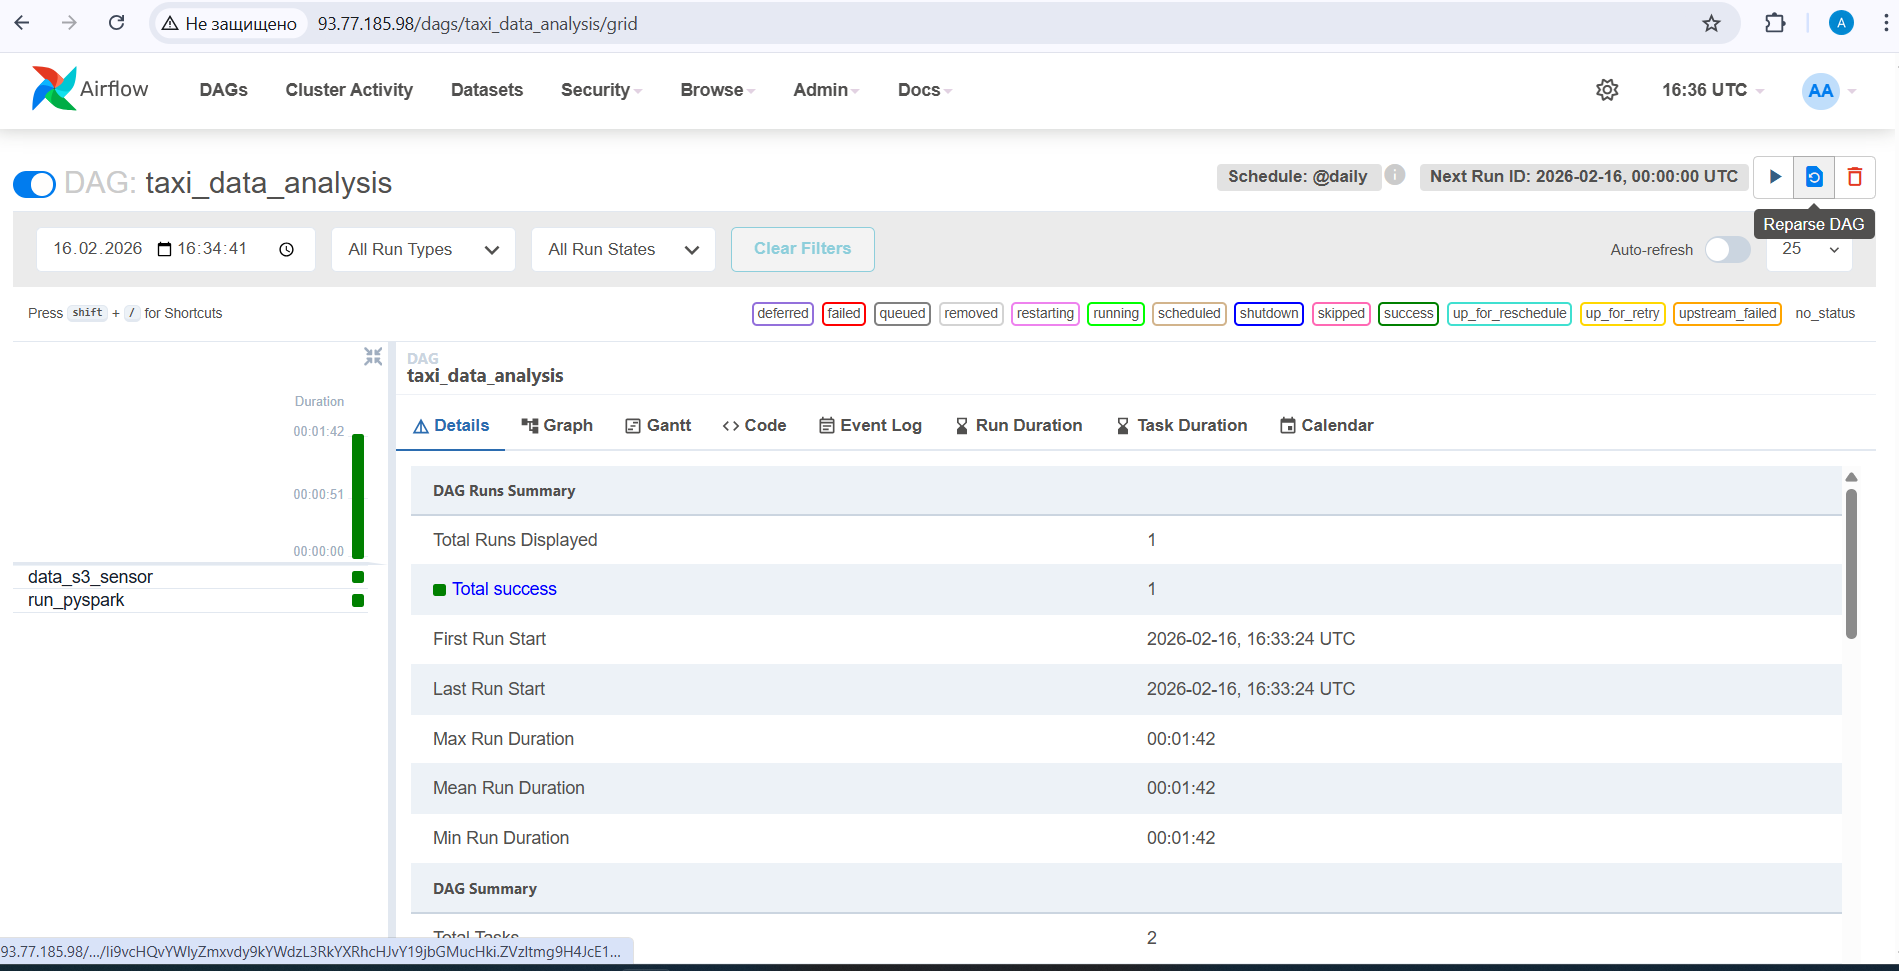

DAG успешно запущен.

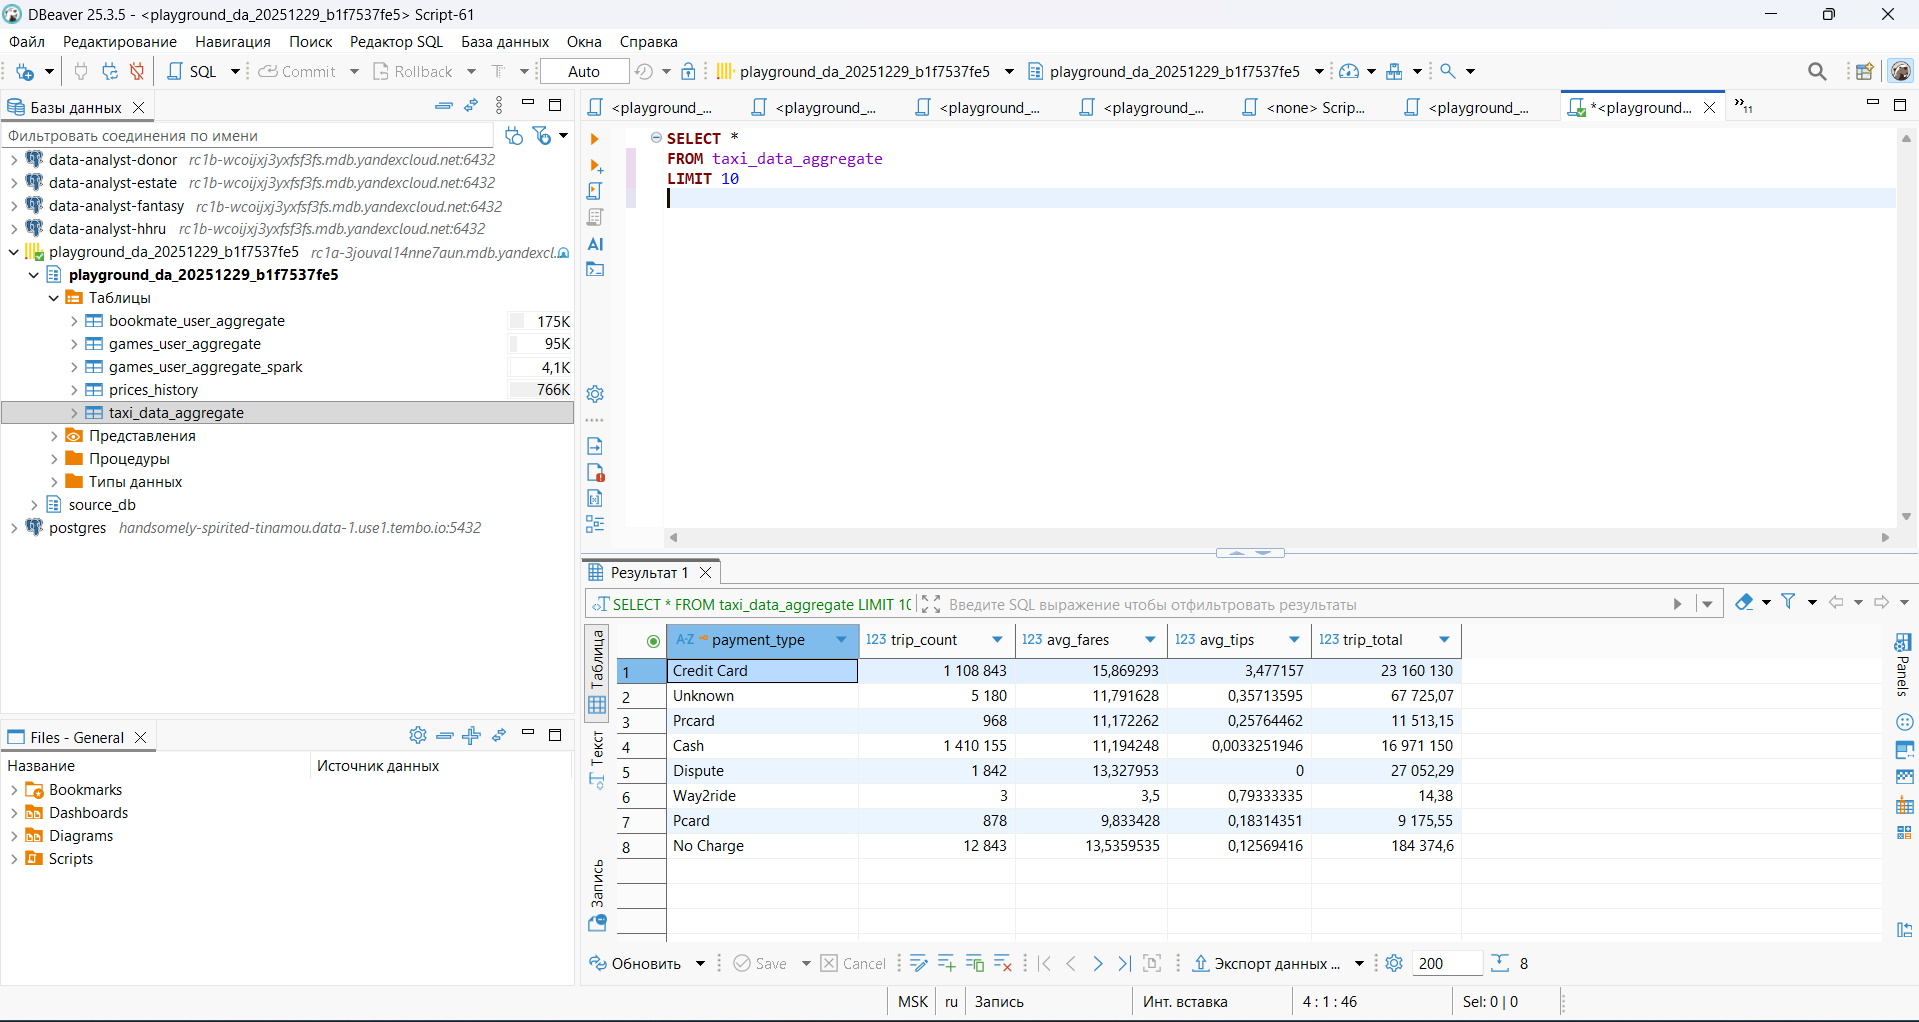

Результаты агрегации в DBeaver.